In [1]:
from sklearn.datasets import make_classification
import numpy as np


In [22]:
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=10)

In [23]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [4]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

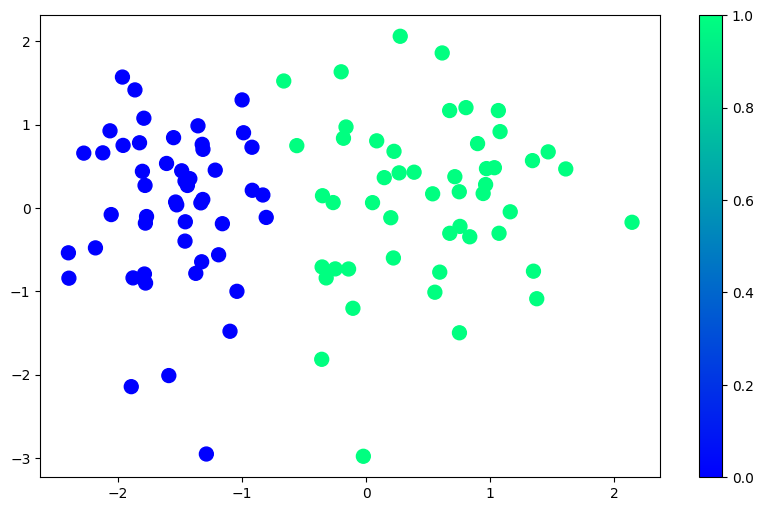

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.colorbar()
plt.show()

In [ ]:
def perceptron(X,y,lr=0.1,epochs=1000):
    x=np.insert(X,0,1,axis=1)
    weights=np.ones(x.shape[1])

    for i in range(epochs):
        j=np.random.randint(0,len(X))
        y_hat=step(np.dot(X[j],weights))
        l=y[j]-y_hat
        weights=weights+lr*l*x[j]

        intercept_=weights[0]
        coef_=weights[1:]

        return intercept_,coef_

In [ ]:
intercept_,coef_=perceptron(X,y)
print("Intercept",intercept_)
print("coefficients",coef_)

Intercept 0.9
coefficients [1.13215269 0.92359908]


In [9]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [10]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input +b

(-3.0, 2.0)

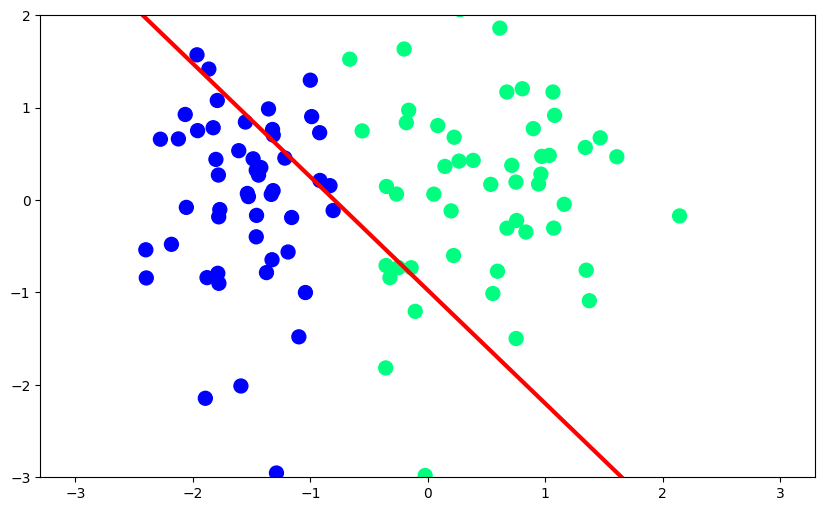

In [11]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [ ]:
def perceptron(X,y):
    m=[]
    b=[]
    x=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1

    for i in range(200):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(x[j],weights))
        weights=weights+lr*(y[i]-y_hat)*x[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0])/weights[2])
    return m,b

In [13]:

from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

(-3.0, 3.0)

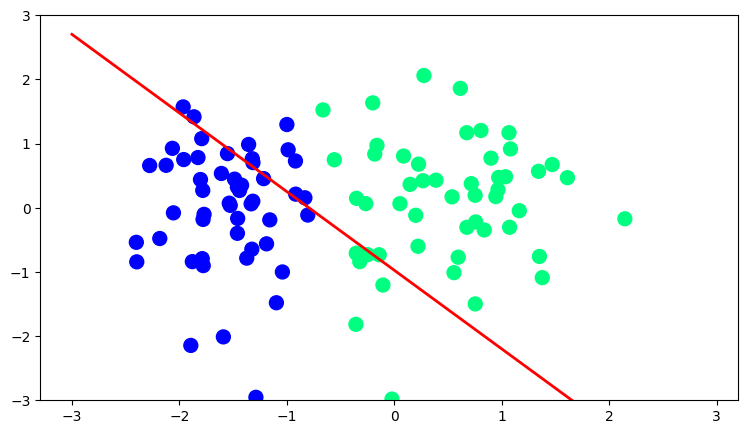

In [19]:
fig,ax=plt.subplots(figsize=(9,5))
x_i=np.arange(-3,3,0.1)
y_i=x_i*m + b
ax.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
line=ax.plot(x_i,y_i,'r-',linewidth=2)
plt.ylim(-3,3)


In [18]:
def update(i):
    label='epoch {0}'.format(i+1)
    line.set_ydata(x_i*m[i]+b[i])
    ax.set(label)

In [20]:
anim=FuncAnimation(fig,update,repeat=True,fargs=200,interval=100)

C:\Users\rajpu\AppData\Local\Temp\ipykernel_17928\3913354692.py:1: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim=FuncAnimation(fig,update,repeat=True,fargs=200,interval=100)
